# Mean-degree model at $C\propto N$: β, higher moments, growth tent

Characterize the **mean-degree** normalization (`kind="powerlaw"`, pl2.5 graph) at the
size-independent scaling $C\propto N$ found earlier ($C=C_0\,N/N_0$, anchor $(4000,100)$).
Here $N=8000\Rightarrow C=200$.

Measured, pooling ~20 realizations:
- **β** — size-volatility exponent $\sigma(\bar S)\sim\bar S^{-\beta}$ (decline branch)
- **higher moments** — $E[\sigma^q\mid S]\sim S^{-\zeta_q}$, $q=1..4$, and the ratios $\zeta_q/\zeta_1$
  vs the granular-flat and MSB references
- **growth-rate distribution** — the tent $g=\Delta\ln S$

The plots show the **binned data points against the fitted lines** so you can judge visually whether
each log-log relation is actually straight (a clean power law) or curved, and whether the tent is
fat-tailed and symmetric.

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
from scipy.stats import laplace
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate, growth_rate
from relative_glv.msb import size_volatility, tent_stats, rescale

SMOKE = os.environ.get("MC_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N0, C0 = 4000, 100                                  # C ∝ N anchor
N = 1500 if SMOKE else 8000
Cdeg = max(2, round(C0 * N / N0))                   # C ∝ N  -> 200 at N=8000
SEEDS = 3 if SMOKE else 20
TMAX, N_EVAL = (100.0, 400) if SMOKE else (250.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (180.0, 240.0)), 0.5
NB, NJOBS = 20, 6
print(f"{'SMOKE ' if SMOKE else ''}mean-degree pl2.5  N={N}  C={Cdeg} (C∝N)  {SEEDS} seeds  "
      f"mu={MU} sigma={SIGMA} lam={LAM}  window={LATE}")

mean-degree pl2.5  N=8000  C=200 (C∝N)  20 seeds  mu=1.76 sigma=1.75 lam=0.001  window=(180.0, 240.0)


In [2]:
def simulate(seed):
    a = coupling(N, MU, SIGMA, kind="powerlaw", seed=seed, mean_degree=Cdeg)
    r = integrate(a, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
    if sv["growth"].size == 0 or not np.isfinite(sv["beta"]):
        return None
    return dict(Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"], beta=float(sv["beta"]),
                r2=float(sv["r2"]), g_eff=growth_rate(r["t"], r["lnM"], frac=0.3))

t0 = time.time()
recs = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
    delayed(simulate)(s) for s in range(SEEDS)) if x is not None]
assert recs, "no economies survived"
Sbar = np.concatenate([x["Sbar"] for x in recs])
vol = np.concatenate([x["vol"] for x in recs])
growth = np.vstack([x["growth"] for x in recs])
econ = np.concatenate([np.full(x["Sbar"].size, i) for i, x in enumerate(recs)])
live = (vol > 0) & np.isfinite(vol) & (Sbar > 0)
Sbar, vol, growth, econ = Sbar[live], vol[live], growth[live], econ[live]
beta_med = float(np.median([x["beta"] for x in recs]))
beta_sd = float(np.std([x["beta"] for x in recs]))
print(f"survived {len(recs)}/{SEEDS}   pooled firms={Sbar.size}   "
      f"beta(median per-economy)={beta_med:.3f} ± {beta_sd:.3f}   "
      f"g_eff~{np.median([x['g_eff'] for x in recs]):+.2f}   ({(time.time()-t0)/60:.1f} min)")

survived 20/20   pooled firms=25992   beta(median per-economy)=0.418 ± 0.089   g_eff~+0.20   (1.5 min)


In [3]:
def multiscaling(Sbar, vol, econ, nb=NB, nboot=300):
    """zeta_1..4 from E[sigma^q|S]~S^-zeta_q on the decline branch, with per-q fit R^2 (linearity)
    and bootstrap-over-economy errors. Same estimator as scripts/msb_conditional.py."""
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by)); Scut = bx[pk]; dec = Sbar > Scut
    nfit = max(6, nb - pk)
    def cq_of(Sx, vx, want_r2=False):
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
        bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []; D2 = []; r2 = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px]); D2.append(byy)
            mm = (bxx > 0) & (byy > 0)
            c = np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)
            out.append(-c[0])
            if want_r2:
                yh = np.polyval(c, np.log10(bxx[mm])); lg = np.log10(byy[mm])
                ss = np.sum((lg - lg.mean()) ** 2)
                r2.append(1 - np.sum((lg - yh) ** 2) / ss if ss > 0 else np.nan)
        return np.array(out), bxx, np.array(D2), np.array(r2) if want_r2 else None
    cq, bxd, D2M, r2q = cq_of(Sbar[dec], vol[dec], want_r2=True)
    ue = np.unique(econ[dec]); rbs = np.random.default_rng(0); boot = []
    for _ in range(nboot):
        pick = rbs.choice(ue, ue.size, replace=True)
        ix = np.concatenate([np.where(econ[dec] == e)[0] for e in pick])
        boot.append(cq_of(Sbar[dec][ix], vol[dec][ix])[0])
    boot = np.array(boot)
    return dict(cq=cq, cq_err=boot.std(0), r2q=r2q, ratio=cq / cq[0],
                ratio_err=(boot / boot[:, [0]]).std(0), bxd=bxd, D2M=D2M,
                bin_S=bx, bin_vol=by, pk=pk, Scut=float(Scut))

ms = multiscaling(Sbar, vol, econ)
ts = tent_stats(growth)
print("higher moments  E[sigma^q|S] ~ S^-zeta_q  (decline branch; MSB data zeta ~ 0.20,0.39,0.51,0.58)")
for q in (1, 2, 3, 4):
    print(f"  q={q}:  zeta_{q} = {ms['cq'][q-1]:+.3f} ± {ms['cq_err'][q-1]:.3f}   "
          f"fit R2 = {ms['r2q'][q-1]:.3f}   (zeta_1 = beta)")
print(f"\nratios zeta_q/zeta_1 = {np.round(ms['ratio'],2).tolist()}   "
      f"(granular flat 1,1,1,1 ; MSB data 1, 2.0, 2.6, 2.9)")
print(f"growth tent: Bowley skew = {ts['bowley']:+.3f} (0=symmetric)   "
      f"excess kurtosis = {ts['exkurt']:.2f} (Gaussian 0, Laplace 3)")

higher moments  E[sigma^q|S] ~ S^-zeta_q  (decline branch; MSB data zeta ~ 0.20,0.39,0.51,0.58)
  q=1:  zeta_1 = +0.358 ± 0.044   fit R2 = 0.951   (zeta_1 = beta)
  q=2:  zeta_2 = +0.587 ± 0.082   fit R2 = 0.953   (zeta_1 = beta)
  q=3:  zeta_3 = +0.713 ± 0.121   fit R2 = 0.951   (zeta_1 = beta)
  q=4:  zeta_4 = +0.760 ± 0.157   fit R2 = 0.937   (zeta_1 = beta)

ratios zeta_q/zeta_1 = [1.0, 1.64, 1.99, 2.12]   (granular flat 1,1,1,1 ; MSB data 1, 2.0, 2.6, 2.9)
growth tent: Bowley skew = -0.013 (0=symmetric)   excess kurtosis = 11.64 (Gaussian 0, Laplace 3)


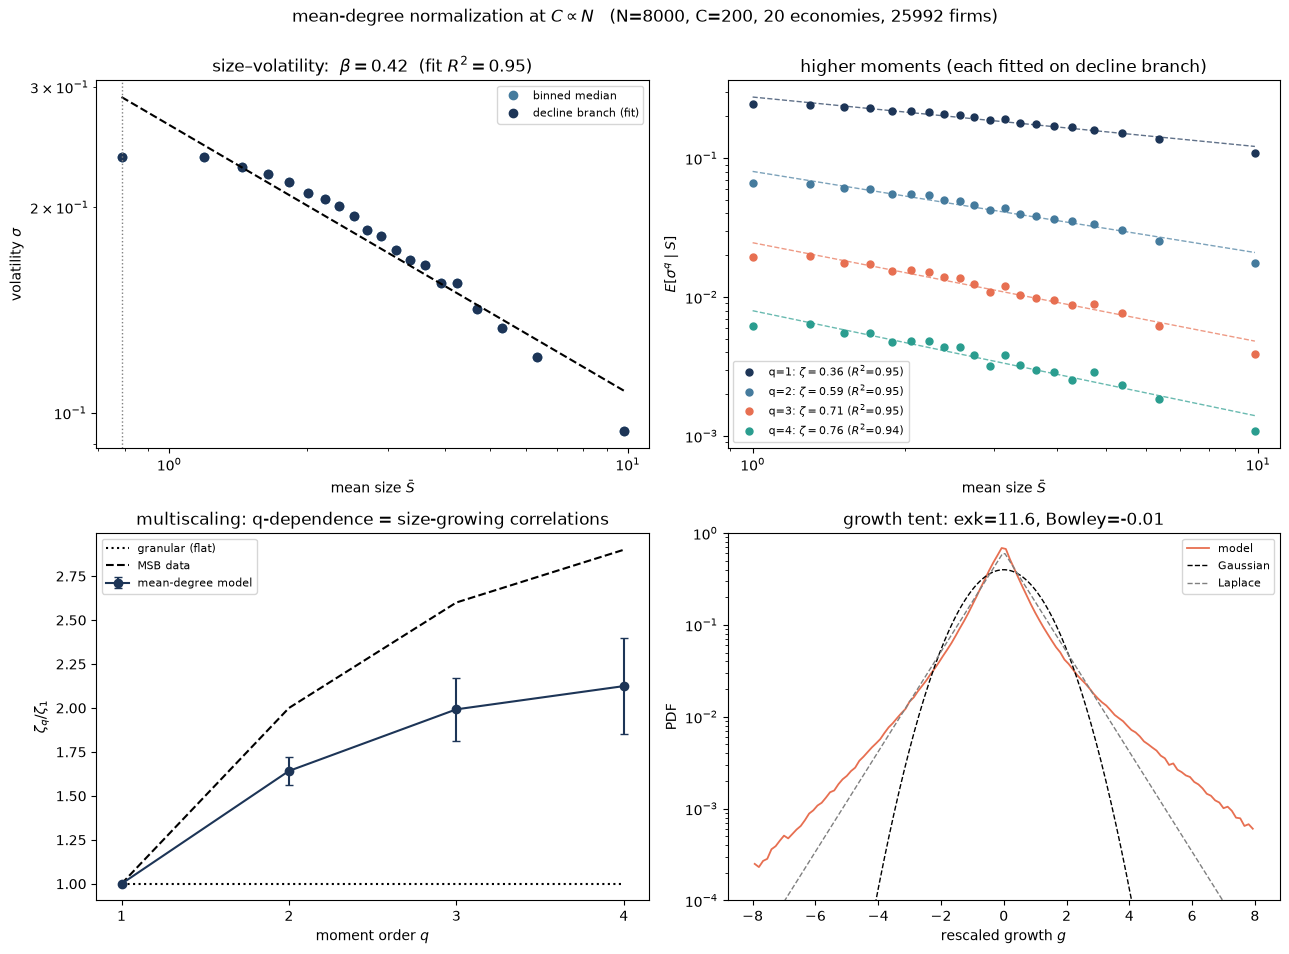

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9.5))
qs = np.array([1, 2, 3, 4]); qcol = ["#1d3557", "#457b9d", "#e76f51", "#2a9d8f"]

# (0,0) size-volatility: full binned curve + decline-branch fit -> is the decline STRAIGHT?
bx, by, pk = ms["bin_S"], ms["bin_vol"], ms["pk"]
ax[0, 0].loglog(bx, by, "o", ms=6, color="#457b9d", label="binned median")
ax[0, 0].loglog(bx[pk:], by[pk:], "o", ms=6, color="#1d3557", label="decline branch (fit)")
xf = np.array([bx[pk], bx[-1]]); cf = np.polyfit(np.log10(bx[pk:]), np.log10(by[pk:]), 1)
ax[0, 0].loglog(xf, 10 ** np.polyval(cf, np.log10(xf)), "k--", lw=1.5)
ax[0, 0].axvline(ms["Scut"], color="grey", ls=":", lw=1)
ax[0, 0].set(xlabel=r"mean size $\bar S$", ylabel=r"volatility $\sigma$",
             title=fr"size–volatility:  $\beta={beta_med:.2f}$  (fit $R^2={ms['r2q'][0]:.2f}$)")
ax[0, 0].legend(fontsize=8)

# (0,1) higher moments E[sigma^q|S] with fit lines -> is each one STRAIGHT?
bxd, D2M = ms["bxd"], ms["D2M"]
for i, q in enumerate(qs):
    ax[0, 1].loglog(bxd, D2M[i], "o", ms=5, color=qcol[i],
                    label=fr"q={q}: $\zeta={ms['cq'][i]:.2f}$ ($R^2$={ms['r2q'][i]:.2f})")
    cf = np.polyfit(np.log10(bxd), np.log10(D2M[i]), 1)
    ax[0, 1].loglog(bxd, 10 ** np.polyval(cf, np.log10(bxd)), "--", lw=1, color=qcol[i], alpha=0.7)
ax[0, 1].set(xlabel=r"mean size $\bar S$", ylabel=r"$E[\sigma^q\mid S]$",
             title="higher moments (each fitted on decline branch)")
ax[0, 1].legend(fontsize=8)

# (1,0) multiscaling ratio zeta_q/zeta_1 vs references
ax[1, 0].errorbar(qs, ms["ratio"], yerr=ms["ratio_err"], marker="o", ms=6, capsize=3,
                  color="#1d3557", label="mean-degree model")
ax[1, 0].plot(qs, [1, 1, 1, 1], "k:", lw=1.5, label="granular (flat)")
ax[1, 0].plot(qs, [1, 2.0, 2.6, 2.9], "k--", lw=1.5, label="MSB data")
ax[1, 0].set(xlabel="moment order $q$", ylabel=r"$\zeta_q/\zeta_1$", xticks=qs,
             title="multiscaling: q-dependence = size-growing correlations")
ax[1, 0].legend(fontsize=8)

# (1,1) growth tent
z = rescale(growth); zz = np.linspace(-8, 8, 200)
h, e = np.histogram(z, bins=120, range=(-8, 8), density=True); m = h > 0
ax[1, 1].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], lw=1.3, color="#e76f51", label="model")
ax[1, 1].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[1, 1].semilogy(zz, laplace.pdf(zz, scale=np.sqrt(2 / np.pi)), "0.5", ls="--", lw=1, label="Laplace")
ax[1, 1].set(xlabel=r"rescaled growth $g$", ylabel="PDF", ylim=(1e-4, 1),
             title=fr"growth tent: exk={ts['exkurt']:.1f}, Bowley={ts['bowley']:+.2f}")
ax[1, 1].legend(fontsize=8)

fig.suptitle(f"mean-degree normalization at $C\\propto N$   (N={N}, C={Cdeg}, {len(recs)} economies, "
             f"{Sbar.size} firms)", y=1.00)
plt.tight_layout()
plt.savefig("data/meandeg_characterize.png", dpi=120)
plt.show()

In [5]:
np.savez("data/meandeg_characterize.npz", N=N, C=Cdeg, seeds=len(recs), n_firms=int(Sbar.size),
         beta=beta_med, beta_sd=beta_sd, cq=ms["cq"], cq_err=ms["cq_err"], r2q=ms["r2q"],
         ratio=ms["ratio"], ratio_err=ms["ratio_err"], bin_S=ms["bin_S"], bin_vol=ms["bin_vol"],
         d2_S=ms["bxd"], d2_M=ms["D2M"], bowley=ts["bowley"], exk=ts["exkurt"],
         tent_z=rescale(growth)[::max(1, growth.size // 40000)].astype(np.float32))
print("saved data/meandeg_characterize.npz and data/meandeg_characterize.png")

saved data/meandeg_characterize.npz and data/meandeg_characterize.png


## How to read the panels

- **Top-left (size–volatility):** is the dark decline branch a **straight line** on log-log? If yes,
  $\sigma(\bar S)\sim\bar S^{-\beta}$ is a clean power law and β is well-defined. Curvature means the
  single exponent is only approximate. (The light small-$\bar S$ points are the immigration-floor
  plateau, excluded from the fit.)
- **Top-right (higher moments):** each $q$ should be straight and parallel-ish; the per-$q$ $R^2$
  quantifies it. Steeper slopes at higher $q$ = multiscaling.
- **Bottom-left (ratios):** on the MSB dashed line = reproduces the size-growing correlations; on the
  flat dotted line = granular/no multiscaling. This is where mean-degree may differ from own-degree.
- **Bottom-right (tent):** heavier-than-Gaussian and roughly symmetric (Bowley≈0) = the fat-tailed
  growth fact.

Change `N` at the top (C tracks it by $C\propto N$) to confirm the picture is size-stable.